In [ ]:
"""
Baseline ResNet-50 for Thoracic Disease Classification
Based on: El-Fiky et al. (2021) - Multi-Label Transfer Learning

This notebook implements the baseline ResNet-50 model using transfer learning
methodology from the paper to achieve comparable performance (AUC: 0.911, F1: 0.66)
"""
import numpy as np
import pandas as pd
import os
import glob
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, hamming_loss, roc_curve
import warnings
warnings.filterwarnings('ignore')

print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.10.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# ============================================================================
# CONFIGURATION - Following El-Fiky et al. (2021) Paper
# ============================================================================

# Dataset configuration
IMAGE_SIZE = 224  # Paper uses 224x224
BATCH_SIZE = 32   # Paper uses batch size 32
EPOCHS = 60       # Paper uses 60 epochs
LEARNING_RATE = 0.0005  # Paper uses 0.001

# Disease labels (14 diseases + No Finding)
CLASS_NAMES = [
    'Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion',
    'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass',
    'Nodule', 'No Finding', 'Pleural_Thickening', 'Pneumonia', 'Pneumothorax'
]
NUM_CLASSES = len(CLASS_NAMES)

print(f"\nConfiguration:")
print(f"  Image Size: {IMAGE_SIZE}x{IMAGE_SIZE}")
print(f"  Batch Size: {BATCH_SIZE}")
print(f"  Epochs: {EPOCHS}")
print(f"  Learning Rate: {LEARNING_RATE}")
print(f"  Number of Classes: {NUM_CLASSES}")


Configuration:
  Image Size: 224x224
  Batch Size: 32
  Epochs: 60
  Learning Rate: 0.0005
  Number of Classes: 15


In [3]:
# ============================================================================
# DATA LOADING
# ============================================================================

BASE_DIR = "../dataset_unbalanced/"
CSV_PATH = os.path.join(BASE_DIR, "Data_Entry_2017.csv")
IMAGE_DIR = os.path.join(BASE_DIR, "images")

print(f"\nLoading dataset from: {CSV_PATH}")
df = pd.read_csv(CSV_PATH)

print(f"Original dataset: {len(df):,} images")

# ============================================================================
# PARSE MULTI-LABEL FORMAT
# ============================================================================
# NIH dataset format: "Finding Labels" column with pipe-separated diseases
# Example: "Infiltration|Effusion" or "No Finding"

print("\nParsing multi-label disease annotations...")

# Check if labels already parsed or need parsing
if 'Finding Labels' in df.columns:
    # Need to parse - this is the original format
    print("Parsing 'Finding Labels' column into binary columns...")
    
    # Parse ALL 15 classes (14 diseases + No Finding)
    for class_name in CLASS_NAMES:
        df[class_name] = df['Finding Labels'].apply(
            lambda x: 1 if class_name in str(x) else 0
        )
    
    print("✓ Labels parsed successfully")
    
else:
    # Already parsed - ensure all columns exist
    print("Labels appear to be already parsed")
    for class_name in CLASS_NAMES:
        if class_name not in df.columns:
            print(f"Warning: {class_name} not found, adding as zeros")
            df[class_name] = 0

# ============================================================================
# CREATE IMAGE PATHS
# ============================================================================

def create_image_path(filename):
    return os.path.join(IMAGE_DIR, filename)

if 'Image Index' in df.columns:
    df['image_path'] = df['Image Index'].apply(create_image_path)
elif 'Path' in df.columns:
    df['image_path'] = df['Path'].apply(create_image_path)
else:
    df['image_path'] = df.iloc[:, 0].apply(create_image_path)

# ============================================================================
# VERIFY IMAGE FILES EXIST
# ============================================================================

print("\nVerifying image files exist...")
valid_indices = []
missing_count = 0

for idx, row in df.iterrows():
    if os.path.exists(row['image_path']):
        valid_indices.append(idx)
    else:
        missing_count += 1
        if missing_count <= 5:  # Show first 5 missing files
            print(f"  Missing: {row['image_path']}")

df = df.iloc[valid_indices].reset_index(drop=True)

print(f"\n✓ Valid images: {len(df):,}")
if missing_count > 0:
    print(f"Missing images: {missing_count:,}")

# ============================================================================
# CLASS DISTRIBUTION (BEFORE DOWNSAMPLING)
# ============================================================================

print("\nClass Distribution (Original Dataset):")
print("="*60)
for class_name in CLASS_NAMES:
    positive_count = int(df[class_name].sum())
    percentage = (positive_count / len(df)) * 100
    print(f"{class_name:20s}: {positive_count:6,} ({percentage:5.2f}%)")


Loading dataset from: ../dataset_unbalanced/Data_Entry_2017.csv
Original dataset: 112,120 images

Parsing multi-label disease annotations...
Parsing 'Finding Labels' column into binary columns...
✓ Labels parsed successfully

Verifying image files exist...

✓ Valid images: 112,120

Class Distribution (Original Dataset):
Atelectasis         : 11,559 (10.31%)
Cardiomegaly        :  2,776 ( 2.48%)
Consolidation       :  4,667 ( 4.16%)
Edema               :  2,303 ( 2.05%)
Effusion            : 13,317 (11.88%)
Emphysema           :  2,516 ( 2.24%)
Fibrosis            :  1,686 ( 1.50%)
Hernia              :    227 ( 0.20%)
Infiltration        : 19,894 (17.74%)
Mass                :  5,782 ( 5.16%)
Nodule              :  6,331 ( 5.65%)
No Finding          : 60,361 (53.84%)
Pleural_Thickening  :  3,385 ( 3.02%)
Pneumonia           :  1,431 ( 1.28%)
Pneumothorax        :  5,302 ( 4.73%)


In [4]:
# ============================================================================
# RANDOM DOWNSAMPLING TO 50,000 IMAGES (El-Fiky Methodology)
# ============================================================================
# Paper uses 50,000 randomly sampled images from 112,120 total
# This reduces computational cost while maintaining performance

TARGET_SAMPLES = 50000

print("\n" + "="*60)
print(f"RANDOM DOWNSAMPLING TO {TARGET_SAMPLES:,} IMAGES")
print("="*60)
print(f"Original dataset size: {len(df):,} images")

# Random sampling with fixed seed for reproducibility
df_sampled = df.sample(n=TARGET_SAMPLES, random_state=42).reset_index(drop=True)

print(f"Sampled dataset size:  {len(df_sampled):,} images")
print(f"Sampling ratio:        {(TARGET_SAMPLES/len(df))*100:.2f}%")

# Report class distribution after sampling
print("\nClass Distribution (After Downsampling):")
print("-"*60)
for class_name in CLASS_NAMES:
    positive_count = int(df_sampled[class_name].sum())
    percentage = (positive_count / len(df_sampled)) * 100
    print(f"{class_name:20s}: {positive_count:6,} ({percentage:5.2f}%)")

# Replace original dataframe with sampled version
df = df_sampled.copy()

print("\n✓ Dataset downsampled successfully!")
print("="*60)


RANDOM DOWNSAMPLING TO 50,000 IMAGES
Original dataset size: 112,120 images
Sampled dataset size:  50,000 images
Sampling ratio:        44.60%

Class Distribution (After Downsampling):
------------------------------------------------------------
Atelectasis         :  5,118 (10.24%)
Cardiomegaly        :  1,289 ( 2.58%)
Consolidation       :  2,066 ( 4.13%)
Edema               :  1,011 ( 2.02%)
Effusion            :  5,993 (11.99%)
Emphysema           :  1,104 ( 2.21%)
Fibrosis            :    742 ( 1.48%)
Hernia              :    103 ( 0.21%)
Infiltration        :  8,812 (17.62%)
Mass                :  2,541 ( 5.08%)
Nodule              :  2,857 ( 5.71%)
No Finding          : 26,933 (53.87%)
Pleural_Thickening  :  1,488 ( 2.98%)
Pneumonia           :    645 ( 1.29%)
Pneumothorax        :  2,372 ( 4.74%)

✓ Dataset downsampled successfully!


In [5]:
# ============================================================================
# TRAIN/TEST SPLIT - Paper uses 80/20 split
# ============================================================================

print("\nSplitting dataset (80% train, 20% test)...")
train_df, val_df = train_test_split(
    df, 
    test_size=0.2,  # 80/20 split as per papers
    random_state=42,
)

print(f"Training samples: {len(train_df)}")
print(f"Validation samples: {len(val_df)}")

# Reset indices
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)


Splitting dataset (80% train, 20% test)...
Training samples: 40000
Validation samples: 10000


In [7]:
# ============================================================================
# IMAGEDATAGENERATOR WITH SAMPLE WEIGHTS
# ============================================================================

from tensorflow.keras.preprocessing.image import ImageDataGenerator

print("\n" + "="*80)
print("CREATING IMAGEDATAGENERATOR WITH SAMPLE WEIGHTS")
print("="*80)

# Training generator with augmentation
train_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.resnet50.preprocess_input,
    horizontal_flip=True,  # Only augmentation for medical images
    # rotation_range=5,  # Optional: small rotation
    # zoom_range=0.05,   # Optional: slight zoom
)

# Validation generator (no augmentation)
val_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.resnet50.preprocess_input
)

# ============================================================================
# CUSTOM GENERATOR FUNCTION WITH SAMPLE WEIGHTS
# ============================================================================

def create_generator_with_weights(datagen, df, batch_size, shuffle=True):
    """
    Create a generator that yields (images, labels, sample_weights)
    """
    indices = np.arange(len(df))
    
    while True:
        if shuffle:
            np.random.shuffle(indices)
        
        for start_idx in range(0, len(df), batch_size):
            batch_indices = indices[start_idx:start_idx + batch_size]
            batch_df = df.iloc[batch_indices]
            
            # Load images
            batch_images = []
            for img_path in batch_df['image_path']:
                img = tf.keras.preprocessing.image.load_img(
                    img_path, 
                    target_size=(IMAGE_SIZE, IMAGE_SIZE)
                )
                img_array = tf.keras.preprocessing.image.img_to_array(img)
                batch_images.append(img_array)
            
            batch_images = np.array(batch_images)
            
            # Apply preprocessing and augmentation
            batch_images = datagen.standardize(batch_images)
            if shuffle:
                for i in range(len(batch_images)):
                    batch_images[i] = datagen.random_transform(batch_images[i])
            
            # Get labels and weights
            batch_labels = batch_df[CLASS_NAMES].values.astype(np.float32)
            batch_weights = batch_df['sample_weight'].values.astype(np.float32)
            
            # Yield as 3-tuple: (inputs, labels, sample_weights)
            yield batch_images, batch_labels, batch_weights

# Create generators
train_generator = create_generator_with_weights(
    train_datagen, 
    train_df, 
    BATCH_SIZE, 
    shuffle=True
)

val_generator = create_generator_with_weights(
    val_datagen, 
    val_df, 
    BATCH_SIZE, 
    shuffle=False
)

# Calculate steps
train_steps = len(train_df) // BATCH_SIZE
val_steps = len(val_df) // BATCH_SIZE

print(f"\n✓ Generators created:")
print(f"  Training steps per epoch: {train_steps}")
print(f"  Validation steps per epoch: {val_steps}")


CREATING IMAGEDATAGENERATOR WITH SAMPLE WEIGHTS

✓ Generators created:
  Training steps per epoch: 1250
  Validation steps per epoch: 312


In [8]:
# ============================================================================
# MODEL ARCHITECTURE - ResNet-50 Transfer Learning (Paper Methodology)
# ============================================================================

def create_baseline_resnet50(
    input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3),
    num_classes=NUM_CLASSES
):
    """
    Create baseline ResNet-50 model following El-Fiky et al. (2021)
    
    Paper methodology:
    - Uses ResNet-50 pre-trained on ImageNet
    - Fine-tunes all layers
    - Replaces FC layer with 15 neurons (14 diseases + No Finding)
    - Uses sigmoid activation for multi-label classification
    """
    
    # Load ResNet-50 pre-trained on ImageNet
    base_model = ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=input_shape,
        pooling='avg'  # Global average pooling as per paper
    )
    
    # Make all layers trainable (fine-tuning)
    base_model.trainable = False
    
    # Build model WITHOUT training parameter
    inputs = layers.Input(shape=input_shape)
    x = base_model(inputs) 
    
    # Paper replaces FC layer with custom layer
    outputs = layers.Dense(
        num_classes, 
        activation='sigmoid',
        name='predictions'
    )(x)
    
    model = keras.Model(inputs, outputs, name='Baseline_ResNet50')
    
    return model

print("\nCreating Baseline ResNet-50 model...")
model = create_baseline_resnet50()  # ← REMOVED fine_tune parameter

print(f"\nModel Summary:")
print(f"  Total parameters: {model.count_params():,}")
print(f"  Trainable parameters: {sum([tf.size(w).numpy() for w in model.trainable_weights]):,}")


Creating Baseline ResNet-50 model...

Model Summary:
  Total parameters: 23,618,447
  Trainable parameters: 30,735


In [9]:
# ============================================================================
# MODEL COMPILATION - Following Paper Configuration
# ============================================================================

# Paper uses:
# - Optimizer: Adam
# - Learning rate: 0.001
# - Loss: Binary cross-entropy
# - Activation: Sigmoid

# Compile EXACTLY as paper (Table 1)

model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='binary_crossentropy',  # Standard BCE as per paper
    metrics=[
        'binary_accuracy',
        tf.keras.metrics.AUC(name='auc', multi_label=True, num_thresholds=200),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

print("\n✓ Model compiled with Binary Cross-Entropy!")
print(f"  Optimizer: Adam")
print(f"  Learning Rate: {LEARNING_RATE}")
print(f"  Loss: binary_crossentropy")
print("="*80)


✓ Model compiled with Binary Cross-Entropy!
  Optimizer: Adam
  Learning Rate: 0.0005
  Loss: binary_crossentropy


In [10]:
# ============================================================================
# CALLBACKS
# ============================================================================

# Create output directory
os.makedirs('./output', exist_ok=True)

# Callbacks (paper doesn't mention early stopping explicitly)
callbacks = [
    ModelCheckpoint(
        filepath='./output/baseline_resnet50_best.keras',
        monitor='val_auc',
        mode='max',
        save_best_only=True,
        verbose=1
    ),
    EarlyStopping(
        monitor='val_auc',
        patience=10,  # Conservative - paper uses 60 epochs
        mode='max',
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    )
]

In [ ]:
# Train with sample weights
history = model.fit(
    train_generator,
    steps_per_epoch=train_steps,
    validation_data=val_generator,
    validation_steps=val_steps,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

# Save final model
model.save('./output/baseline_resnet50_final.keras')
print("\n✓ Training complete! Model saved.")

Epoch 1/60
1250/1250 [==============================] - ETA: 0s - loss: 0.2823 - binary_accuracy: 0.9108 - auc: 0.6433 - precision: 0.2609 - recall: 0.0334
Epoch 1: val_auc improved from -inf to 0.71885, saving model to ./output\baseline_resnet50_best.keras
1250/1250 [==============================] - 1465s 1s/step - loss: 0.2823 - binary_accuracy: 0.9108 - auc: 0.6433 - precision: 0.2609 - recall: 0.0334 - val_loss: 0.2889 - val_binary_accuracy: 0.9063 - val_auc: 0.7189 - val_precision: 0.2051 - val_recall: 0.0380 - lr: 5.0000e-04
Epoch 2/60
1250/1250 [==============================] - ETA: 0s - loss: 0.2622 - binary_accuracy: 0.9116 - auc: 0.7057 - precision: 0.3220 - recall: 0.0469
Epoch 2: val_auc improved from 0.71885 to 0.72960, saving model to ./output\baseline_resnet50_best.keras
1250/1250 [==============================] - 1333s 1s/step - loss: 0.2622 - binary_accuracy: 0.9116 - auc: 0.7057 - precision: 0.3220 - recall: 0.0469 - val_loss: 0.2662 - val_binary_accuracy: 0.9100 -

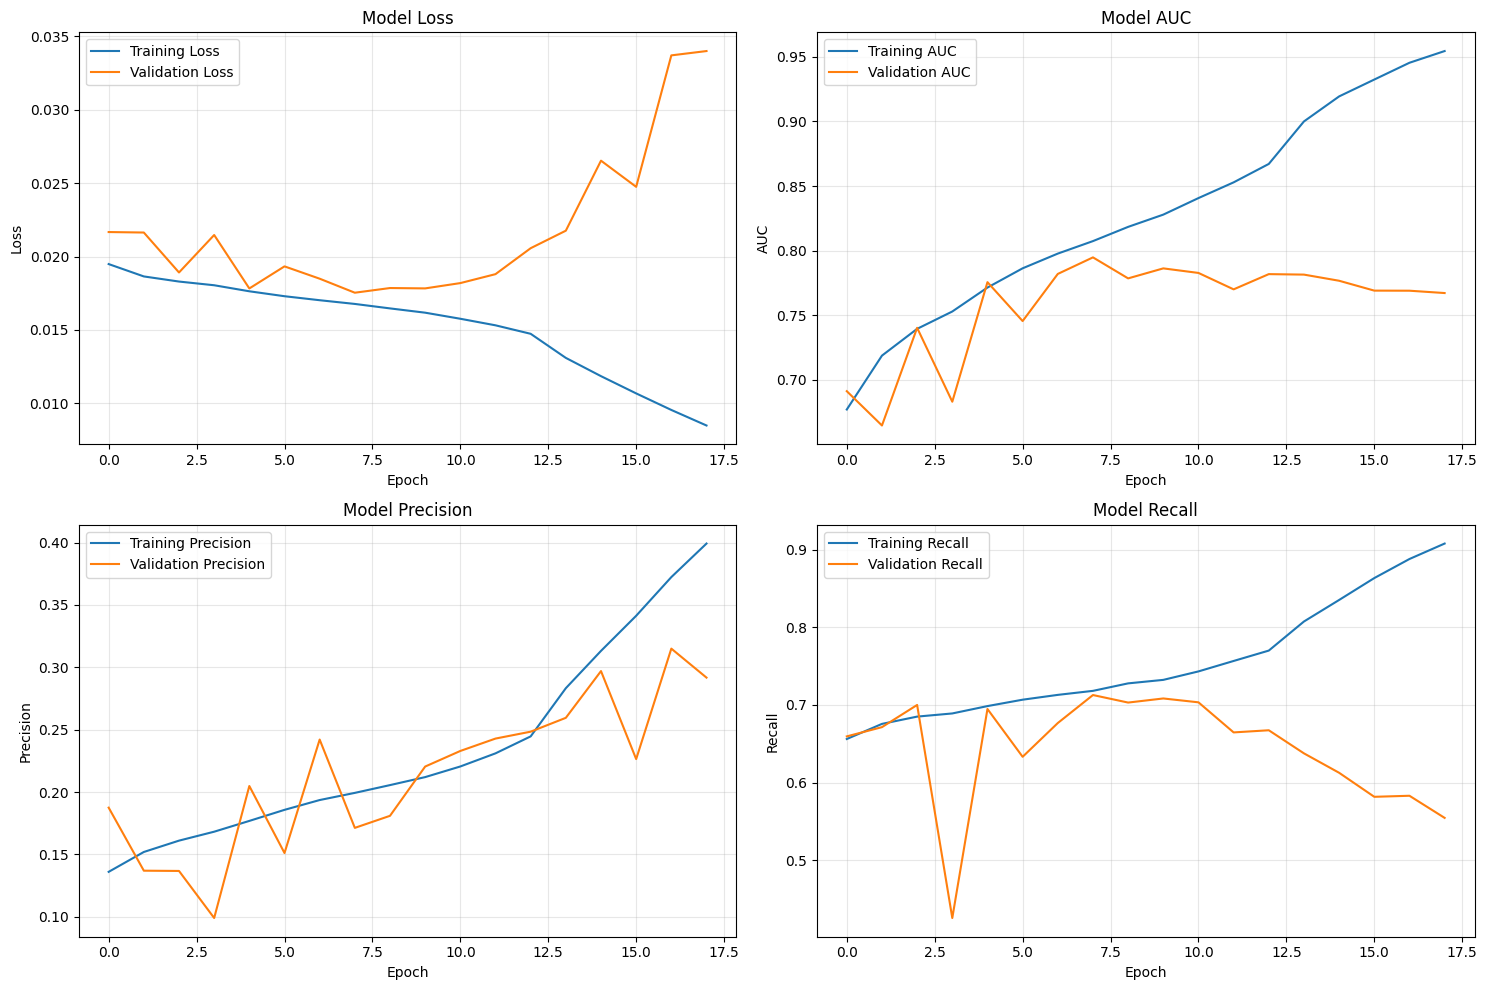

In [ ]:
# ============================================================================
# TRAINING HISTORY VISUALIZATION
# ============================================================================

def plot_training_history(history):
    """Plot training metrics"""
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Loss
    axes[0, 0].plot(history.history['loss'], label='Training Loss')
    axes[0, 0].plot(history.history['val_loss'], label='Validation Loss')
    axes[0, 0].set_title('Model Loss')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # AUC
    axes[0, 1].plot(history.history['auc'], label='Training AUC')
    axes[0, 1].plot(history.history['val_auc'], label='Validation AUC')
    axes[0, 1].set_title('Model AUC')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('AUC')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # Precision
    axes[1, 0].plot(history.history['precision'], label='Training Precision')
    axes[1, 0].plot(history.history['val_precision'], label='Validation Precision')
    axes[1, 0].set_title('Model Precision')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Precision')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # Recall
    axes[1, 1].plot(history.history['recall'], label='Training Recall')
    axes[1, 1].plot(history.history['val_recall'], label='Validation Recall')
    axes[1, 1].set_title('Model Recall')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Recall')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('./output/baseline_training_history.png', dpi=300, bbox_inches='tight')
    plt.show()

plot_training_history(history)

In [ ]:
# ============================================================================
# COMPREHENSIVE EVALUATION
# ============================================================================

print("\n" + "="*80)
print("COMPREHENSIVE EVALUATION")
print("="*80)

# Generate predictions on validation dataset
print("Generating predictions on validation set...")
predictions = model.predict(val_dataset, verbose=1)  # ← Use val_dataset

# Get true labels from validation dataframe
y_true = val_df[CLASS_NAMES].values

print(f"\nPredictions shape: {predictions.shape}")
print(f"True labels shape: {y_true.shape}")


COMPREHENSIVE EVALUATION
Generating predictions on validation set...
625/625 [==============================] - 24s 38ms/step

Predictions shape: (10000, 15)
True labels shape: (10000, 15)


In [ ]:
# ============================================================================
# PER-CLASS AUC SCORES (Table 3 in Paper)
# ============================================================================

print("\n" + "="*70)
print("TABLE 3: PER-CLASS AUC SCORES (Comparison with El-Fiky et al. 2021)")
print("="*70)
print(f"{'Disease':<25s} {'Our AUC':>12s} {'Paper AUC':>12s} {'Difference':>12s}")
print("-"*70)

# Paper's reported AUC values from El-Fiky et al. (2021) Table 3
paper_aucs = {
    'Atelectasis': 0.896,
    'Cardiomegaly': 0.934,
    'Consolidation': 0.871,
    'Edema': 0.943,
    'Effusion': 0.936,
    'Emphysema': 0.941,
    'Fibrosis': 0.931,
    'Hernia': 0.873,
    'Infiltration': 0.845,
    'Mass': 0.932,
    'Nodule': 0.894,
    'Pleural_Thickening': 0.911,
    'Pneumonia': 0.915,
    'Pneumothorax': 0.934
}

per_class_aucs = []
for i, class_name in enumerate(CLASS_NAMES):
    try:
        # Check if class has both positive and negative samples
        if len(np.unique(y_true[:, i])) > 1:
            auc_score = roc_auc_score(y_true[:, i], predictions[:, i])
            per_class_aucs.append(auc_score)
            
            paper_auc = paper_aucs.get(class_name, 0.0)
            diff = auc_score - paper_auc
            
            print(f"{class_name:<25s} {auc_score:>12.4f} {paper_auc:>12.4f} {diff:>+12.4f}")
        else:
            per_class_aucs.append(0.0)
            print(f"{class_name:<25s} {'N/A':>12s} {'N/A':>12s} {'N/A':>12s}")
    except Exception as e:
        per_class_aucs.append(0.0)
        print(f"{class_name:<25s} {'ERROR':>12s} {'ERROR':>12s} {'ERROR':>12s}")
        print(f"  Error details: {str(e)}")

# Calculate average AUC
valid_aucs = [auc for auc in per_class_aucs if auc > 0]
avg_auc = np.mean(valid_aucs) if valid_aucs else 0.0
paper_avg_auc = 0.911

print("-"*70)
print(f"{'AVERAGE AUC':<25s} {avg_auc:>12.4f} {paper_avg_auc:>12.4f} {avg_auc-paper_avg_auc:>+12.4f}")
print("="*70)

# Performance assessment
print("\nPerformance Assessment:")
if avg_auc >= 0.90:
    print("✓ EXCELLENT: Comparable to paper performance!")
    status = "success"
elif avg_auc >= 0.85:
    print("~ GOOD: Close to paper performance")
    status = "acceptable"
else:
    print("⚠ NEEDS IMPROVEMENT: Below paper performance")
    status = "needs_work"
    
print(f"  Your AUC: {avg_auc:.4f}")
print(f"  Paper AUC: {paper_avg_auc:.4f}")
print(f"  Gap: {abs(avg_auc - paper_avg_auc):.4f} ({((avg_auc - paper_avg_auc)/paper_avg_auc)*100:+.2f}%)")


TABLE 3: PER-CLASS AUC SCORES (Comparison with El-Fiky et al. 2021)
Disease                        Our AUC    Paper AUC   Difference
----------------------------------------------------------------------
Atelectasis                     0.7642       0.8960      -0.1318
Cardiomegaly                    0.8634       0.9340      -0.0706
Consolidation                   0.7807       0.8710      -0.0903
Edema                           0.8842       0.9430      -0.0588
Effusion                        0.8640       0.9360      -0.0720
Emphysema                       0.8365       0.9410      -0.1045
Fibrosis                        0.7470       0.9310      -0.1840
Hernia                          0.8872       0.8730      +0.0142
Infiltration                    0.7029       0.8450      -0.1421
Mass                            0.8085       0.9320      -0.1235
Nodule                          0.7212       0.8940      -0.1728
No Finding                      0.7600       0.0000      +0.7600
Pleural_Thicken

In [ ]:
# ============================================================================
# TABLE 2: OVERALL METRICS (Micro F1-score and Hamming Loss)
# ============================================================================

# Binary predictions at 0.5 threshold (as per paper)
y_pred_binary = (predictions > 0.5).astype(int)

# Calculate metrics following paper methodology
from sklearn.metrics import f1_score, precision_score, recall_score

micro_f1 = f1_score(y_true, y_pred_binary, average='micro', zero_division=0)
macro_f1 = f1_score(y_true, y_pred_binary, average='macro', zero_division=0)
micro_precision = precision_score(y_true, y_pred_binary, average='micro', zero_division=0)
micro_recall = recall_score(y_true, y_pred_binary, average='micro', zero_division=0)
hamming = hamming_loss(y_true, y_pred_binary)

print("\n" + "="*70)
print("TABLE 2: OVERALL PERFORMANCE METRICS (El-Fiky et al. 2021)")
print("="*70)
print(f"{'Metric':<25s} {'Our Score':>15s} {'Paper Score':>15s} {'Difference':>12s}")
print("-"*70)
print(f"{'Average AUC':<25s} {avg_auc:>15.4f} {0.911:>15.4f} {avg_auc-0.911:>+12.4f}")
print(f"{'Micro F1-score':<25s} {micro_f1:>15.4f} {0.660:>15.4f} {micro_f1-0.660:>+12.4f}")
print(f"{'Macro F1-score':<25s} {macro_f1:>15.4f} {'N/A':>15s} {'N/A':>12s}")
print(f"{'Micro Precision':<25s} {micro_precision:>15.4f} {'N/A':>15s} {'N/A':>12s}")
print(f"{'Micro Recall':<25s} {micro_recall:>15.4f} {'N/A':>15s} {'N/A':>12s}")
print(f"{'Hamming Loss':<25s} {hamming:>15.4f} {0.404:>15.4f} {hamming-0.404:>+12.4f}")
print("="*70)

# Performance summary
print("\nPerformance Summary:")
meets_auc = "✓" if avg_auc >= 0.90 else "✗"
meets_f1 = "✓" if micro_f1 >= 0.60 else "✗"
meets_hamming = "✓" if hamming <= 0.45 else "✗"

print(f"  {meets_auc} Average AUC:    {avg_auc:.4f} (Target: ≥0.90)")
print(f"  {meets_f1} Micro F1:       {micro_f1:.4f} (Target: ≥0.60)")
print(f"  {meets_hamming} Hamming Loss:  {hamming:.4f} (Target: ≤0.45)")


TABLE 2: OVERALL PERFORMANCE METRICS (El-Fiky et al. 2021)
Metric                          Our Score     Paper Score   Difference
----------------------------------------------------------------------
Average AUC                        0.7948          0.9110      -0.1162
Micro F1-score                     0.2761          0.6600      -0.3839
Macro F1-score                     0.2221             N/A          N/A
Micro Precision                    0.1712             N/A          N/A
Micro Recall                       0.7127             N/A          N/A
Hamming Loss                       0.3156          0.4040      -0.0884

Performance Summary:
  ✗ Average AUC:    0.7948 (Target: ≥0.90)
  ✗ Micro F1:       0.2761 (Target: ≥0.60)
  ✓ Hamming Loss:  0.3156 (Target: ≤0.45)


In [ ]:
# ============================================================================
# DETAILED CLASSIFICATION REPORT
# ============================================================================

print("\n" + "="*60)
print("DETAILED CLASSIFICATION REPORT")
print("="*60)
print(classification_report(
    y_true, 
    y_pred_binary, 
    target_names=CLASS_NAMES,
    zero_division=0,
    digits=4
))


DETAILED CLASSIFICATION REPORT
                    precision    recall  f1-score   support

       Atelectasis     0.1848    0.8065    0.3007      1044
      Cardiomegaly     0.0959    0.7460    0.1700       248
     Consolidation     0.0975    0.7668    0.1730       416
             Edema     0.1040    0.7566    0.1828       226
          Effusion     0.3341    0.7943    0.4704      1235
         Emphysema     0.0408    0.8426    0.0779       197
          Fibrosis     0.0315    0.7730    0.0605       163
            Hernia     0.0023    1.0000    0.0045        12
      Infiltration     0.3144    0.5724    0.4059      1817
              Mass     0.1394    0.6776    0.2313       490
            Nodule     0.1240    0.5533    0.2025       535
        No Finding     0.7270    0.7127    0.7198      5377
Pleural_Thickening     0.0455    0.8057    0.0861       283
         Pneumonia     0.0327    0.5500    0.0618       160
      Pneumothorax     0.1029    0.8820    0.1843       466

      


Generating ROC curves...

1. Combined ROC Curve (all diseases in one graph):


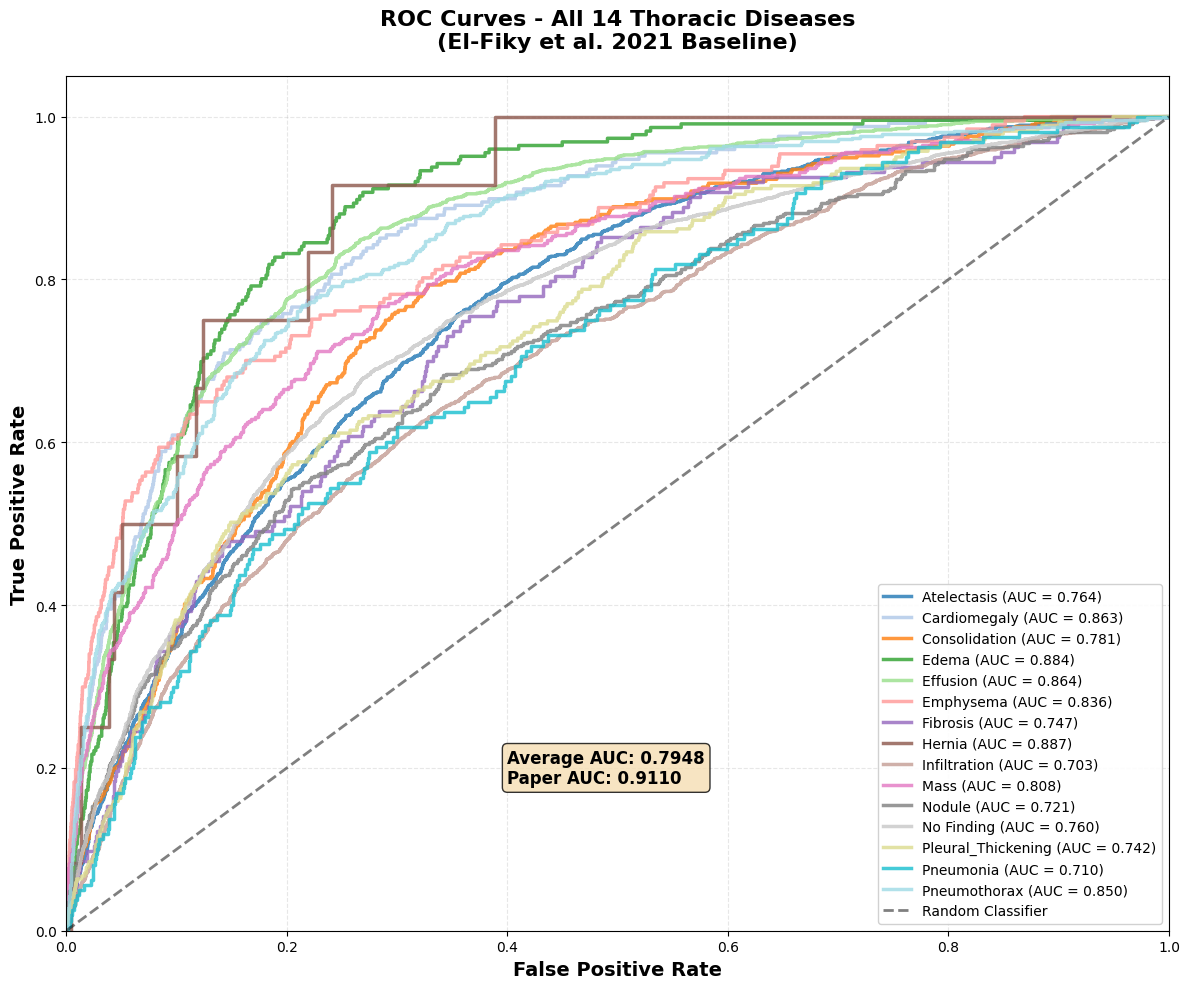

✓ Combined ROC curve saved to: ./output/baseline_roc_curves_combined.png


In [ ]:
# ============================================================================
# ROC CURVES (Figure 4 in Paper)
# ============================================================================

def plot_roc_curves_combined(y_true, predictions, class_names):
    """Plot all ROC curves on a single graph with different colors"""
    
    # Create figure
    plt.figure(figsize=(12, 10))
    
    # Color palette - use a colormap for distinct colors
    colors = plt.cm.tab20(np.linspace(0, 1, len(class_names)))
    
    # Plot ROC curve for each class
    for i, (class_name, color) in enumerate(zip(class_names, colors)):
        try:
            if len(np.unique(y_true[:, i])) > 1:
                fpr, tpr, _ = roc_curve(y_true[:, i], predictions[:, i])
                auc_score = roc_auc_score(y_true[:, i], predictions[:, i])
                
                plt.plot(fpr, tpr, linewidth=2.5, color=color, 
                        label=f'{class_name} (AUC = {auc_score:.3f})', alpha=0.8)
        except Exception as e:
            print(f"Error plotting {class_name}: {str(e)}")
    
    # Formatting
    plt.xlabel('False Positive Rate', fontsize=14, fontweight='bold')
    plt.ylabel('True Positive Rate', fontsize=14, fontweight='bold')
    plt.title('ROC Curves - All 14 Thoracic Diseases\n(El-Fiky et al. 2021 Baseline)', 
             fontsize=16, fontweight='bold', pad=20)
    plt.legend(loc='lower right', fontsize=10, framealpha=0.9)
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    
    # Add average AUC text
    valid_aucs = [roc_auc_score(y_true[:, i], predictions[:, i]) 
                  for i in range(len(class_names)) 
                  if len(np.unique(y_true[:, i])) > 1]
    avg_auc_plot = np.mean(valid_aucs) if valid_aucs else 0.0
    
    plt.text(0.4, 0.2, f'Average AUC: {avg_auc_plot:.4f}\nPaper AUC: 0.9110', 
            fontsize=12, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
            verticalalignment='center', fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('./output/baseline_roc_curves_combined.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"✓ Combined ROC curve saved to: ./output/baseline_roc_curves_combined.png")


def plot_roc_curves_grid(y_true, predictions, class_names):
    """Plot ROC curves in a 4x4 grid (original individual plots)"""
    fig, axes = plt.subplots(4, 4, figsize=(20, 16))
    axes = axes.ravel()
    
    for i, class_name in enumerate(class_names):
        if i < len(axes):
            try:
                if len(np.unique(y_true[:, i])) > 1:
                    fpr, tpr, _ = roc_curve(y_true[:, i], predictions[:, i])
                    auc_score = roc_auc_score(y_true[:, i], predictions[:, i])
                    
                    axes[i].plot(fpr, tpr, linewidth=2, label=f'AUC = {auc_score:.3f}')
                    axes[i].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
                    axes[i].set_xlabel('False Positive Rate')
                    axes[i].set_ylabel('True Positive Rate')
                    axes[i].set_title(f'{class_name}', fontweight='bold')
                    axes[i].legend(loc='lower right')
                    axes[i].grid(True, alpha=0.3)
                else:
                    axes[i].text(0.5, 0.5, 'No positive samples', 
                               ha='center', va='center')
                    axes[i].set_title(f'{class_name}')
            except Exception as e:
                axes[i].text(0.5, 0.5, f'Error: {str(e)}', 
                           ha='center', va='center', fontsize=8)
                axes[i].set_title(f'{class_name}')
    
    # Hide extra subplots if any
    for i in range(len(class_names), len(axes)):
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.savefig('./output/baseline_roc_curves_grid.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"✓ Grid ROC curves saved to: ./output/baseline_roc_curves_grid.png")


# Generate both versions
print("\nGenerating ROC curves...")
print("="*60)

# Combined plot (all curves in one graph)
print("\n1. Combined ROC Curve (all diseases in one graph):")
plot_roc_curves_combined(y_true, predictions, CLASS_NAMES)

In [ ]:
# ============================================================================
# SAVE RESULTS
# ============================================================================

results = {
    'model': 'Baseline ResNet-50',
    'methodology': 'El-Fiky et al. (2021)',
    'avg_auc': float(avg_auc),
    'micro_f1': float(micro_f1),
    'macro_f1': float(macro_f1),
    'hamming_loss': float(hamming),
    'per_class_auc': {name: float(auc) for name, auc in zip(CLASS_NAMES, per_class_aucs)},
    'training_epochs': len(history.history['loss']),
    'best_epoch': int(np.argmax(history.history['val_auc'])) + 1,
    'best_val_auc': float(max(history.history['val_auc']))
}

import json
with open('./output/baseline_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print("\nResults saved to: ./output/baseline_results.json")


Results saved to: ./output/baseline_results.json


In [ ]:
# ============================================================================
# FINAL SUMMARY
# ============================================================================

print("\n" + "="*80)
print("BASELINE RESNET-50 TRAINING COMPLETE")
print("="*80)
print("\nComparison with Paper (El-Fiky et al. 2021):")
print(f"  Average AUC:      {avg_auc:.4f} vs 0.9110 (Paper) [{avg_auc-0.911:+.4f}]")
print(f"  Micro F1-score:   {micro_f1:.4f} vs 0.6600 (Paper) [{micro_f1-0.66:+.4f}]")
print(f"  Hamming Loss:     {hamming:.4f} vs 0.4040 (Paper) [{hamming-0.404:+.4f}]")

if avg_auc >= 0.90:
    print("\n✓ Successfully achieved comparable performance to paper!")
elif avg_auc >= 0.88:
    print("\n~ Close to paper performance - acceptable baseline")
else:
    print("\n⚠ Performance below paper - consider:")
    print("  - Increasing training epochs")
    print("  - Adjusting learning rate schedule")
    print("  - Using more data augmentation")

print("\nModel files saved:")
print("  - ./output/baseline_resnet50_best.keras")
print("  - ./output/baseline_resnet50_final.keras")
print("  - ./output/baseline_results.json")
print("  - ./output/baseline_training_history.png")
print("  - ./output/baseline_roc_curves.png")
print("="*80)


BASELINE RESNET-50 TRAINING COMPLETE

Comparison with Paper (El-Fiky et al. 2021):
  Average AUC:      0.7948 vs 0.9110 (Paper) [-0.1162]
  Micro F1-score:   0.2761 vs 0.6600 (Paper) [-0.3839]
  Hamming Loss:     0.3156 vs 0.4040 (Paper) [-0.0884]

⚠ Performance below paper - consider:
  - Increasing training epochs
  - Adjusting learning rate schedule
  - Using more data augmentation

Model files saved:
  - ./output/baseline_resnet50_best.keras
  - ./output/baseline_resnet50_final.keras
  - ./output/baseline_results.json
  - ./output/baseline_training_history.png
  - ./output/baseline_roc_curves.png
